# I/  supervised regression

### 🎯Objective: prediction of penalty rate by product  based on its characteristics and composition

### 🔍 Justified Choice: Predictive vs. Descriptive Approach
A predictive approach is selected because the objective is to forecast the penalty rates for products in the future, enabling proactive measures rather than simply analyzing existing data patterns.

In [1]:
#!pip install pyodbc

## 1/extract the data

In [2]:
import pyodbc
import pandas as pd

# Connexion à la base de données SQL Server
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"  # Remplace par ton serveur
    "DATABASE=DW_supplyChainProject;"
    "UID=sa;"  # Remplace par ton utilisateur
    "PWD=mariemzorgani26;"  # Remplace par ton mot de passe
)

print("Connexion réussie!")

# Requête SQL pour récupérer les informations des produits et leurs ingrédients
query = """
SELECT Product_Id, Product_Name,Category, Material_Name, Brand_Name
FROM [DW_supplyChainProject].[dbo].[Dim_Product];
"""

# Charger les données dans un DataFrame pandas
df_products = pd.read_sql(query, conn)

# Fermer la connexion
conn.close()
print("Données récupérées avec succès!")

# Afficher les premières lignes du DataFrame
df_products.head()


Connexion réussie!
Données récupérées avec succès!


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7376\4204612027.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query, conn)


,Product_Id,Product_Name,Category,Material_Name,Brand_Name
0,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,AMYL CINNAMAL,Hansen & Co
1,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,CAPRYLIC/CAPRIC TRIGLYCERIDE,Hansen & Co
2,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,COCOS NUCIFERA (COCONUT) OIL,Hansen & Co
3,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,GARDENIA TAITENSIS FLOWER EXTRACT,Hansen & Co
4,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,HELIANTHUS ANNUUS (SUNFLOWER) SEED OIL,Hansen & Co


In [3]:
# Charger le fichier JSON des ingrédients
import json

json_path =  r"E:\data\dataPIII\ingredients.json"

with open(json_path, "r", encoding="utf-8") as file:
    ingredients_data = json.load(file)

# Convertir en DataFrame
df_ingredients = pd.DataFrame(ingredients_data)

# Afficher les premières lignes pour vérifier la structure
df_ingredients.head()


,_id,Pénalité,Origine,Autres_langues,Nom_INCI,N°EINECS/ELINCS,Classification,Bio
0,67a9127a01de1b1e71cff350,"""Pas de pénalité"" dans toutes les catégories.",Non trouvé,Non trouvé,A-TERPINYL ACETATE,201-265-7,Non trouvé,Non compatible Bio
1,67a9127d01de1b1e71cff351,"""Pas de pénalité"" dans toutes les catégories.",Non trouvé,Non trouvé,ABALONE EXTRACT,Non trouvé,Non trouvé,Non compatible Bio
2,67a9127e01de1b1e71cff352,"""Pas de pénalité"" dans toutes les catégories.",Non trouvé,Non trouvé,ABALONE SHELL POWDER,Non trouvé,Non trouvé,Non compatible Bio
3,67a9128001de1b1e71cff353,"""Pas de pénalité"" dans toutes les catégories.",Non trouvé,Non trouvé,ABELIOPHYLLUM DISTICHUM EXTRACT,-,Non trouvé,Non compatible Bio
4,67a9128101de1b1e71cff354,"""Pas de pénalité"" dans toutes les catégories.",Non trouvé,Non trouvé,ABELMOSCHUS ESCULENTUS FRUIT EXTRACT,Non trouvé,Non trouvé,Non compatible Bio


In [4]:
# Normaliser les noms pour éviter les différences de casse et d'espaces
df_products["Material_Name"] = df_products["Material_Name"].str.strip().str.upper()
df_ingredients["Nom_INCI"] = df_ingredients["Nom_INCI"].str.strip().str.upper()

# Fusionner les deux DataFrames sur le nom des ingrédients
df_final = df_products.merge(df_ingredients, left_on="Material_Name", right_on="Nom_INCI", how="left")

# Garder seulement les colonnes pertinentes
df_final = df_final[["Product_Id", "Product_Name","Category", "Material_Name" ,"Brand_Name","Pénalité"]]

# Afficher un aperçu des données fusionnées
df_final.head()


,Product_Id,Product_Name,Category,Material_Name,Brand_Name,Pénalité
0,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,AMYL CINNAMAL,Hansen & Co,"""Pénalité faible"" dans toutes les catégories."
1,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,CAPRYLIC/CAPRIC TRIGLYCERIDE,Hansen & Co,"""Pas de pénalité"" dans toutes les catégories."
2,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,COCOS NUCIFERA (COCONUT) OIL,Hansen & Co,NaN
3,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,GARDENIA TAITENSIS FLOWER EXTRACT,Hansen & Co,NaN
4,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,HELIANTHUS ANNUUS (SUNFLOWER) SEED OIL,Hansen & Co,NaN


## 2/ prepare the data

In [5]:
import pandas as pd
import numpy as np
import re

# Remplacer les NaN par "Inconnu"
df_final["Pénalité"] = df_final["Pénalité"].fillna("Inconnu")

# Nettoyer les espaces et caractères spéciaux dans la colonne "Pénalité"
df_final["Pénalité"] = df_final["Pénalité"].str.strip()

# Enlever les guillemets et les descriptions après "dans les catégories suivantes"
df_final["Pénalité"] = df_final["Pénalité"].apply(lambda x: re.sub(r'"(.*)"', r'\1', x))  # Enlever les guillemets
df_final["Pénalité"] = df_final["Pénalité"].apply(lambda x: re.sub(r'dans les catégories.*', '', x))  # Enlever tout ce qui suit

# Remplacer les valeurs erronées ou mal formatées
df_final["Pénalité"] = df_final["Pénalité"].replace({
    "Pénalité faible": "Pénalité faible dans toutes les catégories.",
    "Pas de pénalité": "Pas de pénalité dans toutes les catégories.",
    "Pénalité forte ": "Pénalité forte dans toutes les catégories.",
    "Pénalité moyenne": "Pénalité moyenne dans toutes les catégories.",
})

# Afficher les valeurs uniques après nettoyage
print(df_final["Pénalité"].unique())

# Définir le mapping
penalite_mapping = {
    "Pas de pénalité dans toutes les catégories.": 0,
    "Pénalité faible dans toutes les catégories.": 1,
    "Pénalité moyenne dans toutes les catégories.": 2,
    "Pénalité forte dans toutes les catégories.": 3
}

# Remplacer les "Inconnu" par la pénalité la plus fréquente (mode)
mode_penalite = df_final[df_final["Pénalité"] != "Inconnu"]["Pénalité"].mode()[0]
df_final.loc[df_final["Pénalité"] == "Inconnu", "Pénalité"] = mode_penalite

# Appliquer le mapping numérique
df_final["Pénalité_Score"] = df_final["Pénalité"].map(penalite_mapping)

# Vérifier qu'il n'y a plus de NaN
df_final["Pénalité_Score"].fillna(penalite_mapping[mode_penalite], inplace=True)

# Afficher les premières lignes
df_final.head(1000)


['Pénalité faible dans toutes les catégories.'
 'Pas de pénalité dans toutes les catégories.' 'Inconnu'
 'Pénalité forte dans toutes les catégories.'
 'Pénalité moyenne dans toutes les catégories.']


,Product_Id,Product_Name,Category,Material_Name,Brand_Name,Pénalité,Pénalité_Score
0,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,AMYL CINNAMAL,Hansen & Co,Pénalité faible dans toutes les catégories.,1
1,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,CAPRYLIC/CAPRIC TRIGLYCERIDE,Hansen & Co,Pas de pénalité dans toutes les catégories.,0
2,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,COCOS NUCIFERA (COCONUT) OIL,Hansen & Co,Pénalité faible dans toutes les catégories.,1
3,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,GARDENIA TAITENSIS FLOWER EXTRACT,Hansen & Co,Pénalité faible dans toutes les catégories.,1
4,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,HELIANTHUS ANNUUS (SUNFLOWER) SEED OIL,Hansen & Co,Pénalité faible dans toutes les catégories.,1
...,...,...,...,...,...,...,...
995,PR-169,Body Scrub 169,Pearson-Smith,SODIUM BENZOATE,Bodycare,Pénalité faible dans toutes les catégories.,1
996,PR-169,Body Scrub 169,Pearson-Smith,LINALOOL,Bodycare,Pénalité faible dans toutes les catégories.,1
997,PR-169,Body Scrub 169,Pearson-Smith,GLYCERYL STEARATE,Bodycare,Pas de pénalité dans toutes les catégories.,0
998,PR-169,Body Scrub 169,Pearson-Smith,LINALOOL,Bodycare,Pénalité faible dans toutes les catégories.,1


### 📄 Interpretation

.Data Cleaning and handling missing values :

        ==>Cleaning the category because it has values ​​included
        ==>Missing values (NaN) in the Pénalité column are replaced with "Inconnu"
        ==>The "Inconnu" values are replaced with the most frequent (mode) penalty value found in the dataset      
.Standardization:

        ==>Text inconsistencies and formatting errors in penalty descriptions are corrected to standardized forms                           (e.g.,  "Pénalité faible" becomes "Pénalité faible dans toutes les catégories.").

.Label Encoding:

        ==>The cleaned penalty descriptions are mapped to numeric scores:
        0 = No penalty /1 = Low penalty /2 = Medium penalty/ 3 = High penalty

In [6]:
import pandas as pd
import json

# Assurez-vous que df_final est votre DataFrame initial
df = pd.DataFrame(df_final)

# Regrouper les données par 'Product_Id' et 'Category', puis concaténer les 'Material_Name' dans une liste
grouped_df = df.groupby(['Product_Id', 'Product_Name', 'Category'])['Material_Name'].apply(list).reset_index()

# Fonction pour générer le JSON à partir du DataFrame
def generate_json_from_df(df):
    data_json = []
    
    # Parcours chaque ligne du DataFrame et l'ajoute au JSON
    for _, row in df.iterrows():
        product_data = {
            "Product_Id": row['Product_Id'],
            "Product_Name": row['Product_Name'],
            "Category": row['Category'],
            "Material_Name": row['Material_Name']  # Maintenant c'est une liste de Material_Name
        }
        data_json.append(product_data)
    
    # Convertir la liste en JSON
    json_data = json.dumps(data_json, indent=4)
    
    return json_data

# Générer le JSON à partir du DataFrame regroupé
json_result = generate_json_from_df(grouped_df)

# Sauvegarder le JSON dans un fichier
file_name = 'product_data_with_material_list.json'
with open(file_name, 'w') as f:
    f.write(json_result)

print(f"Le fichier JSON a été sauvegardé sous le nom {file_name}")


Le fichier JSON a été sauvegardé sous le nom product_data_with_material_list.json


## 3/ Distribution of penalty scores 

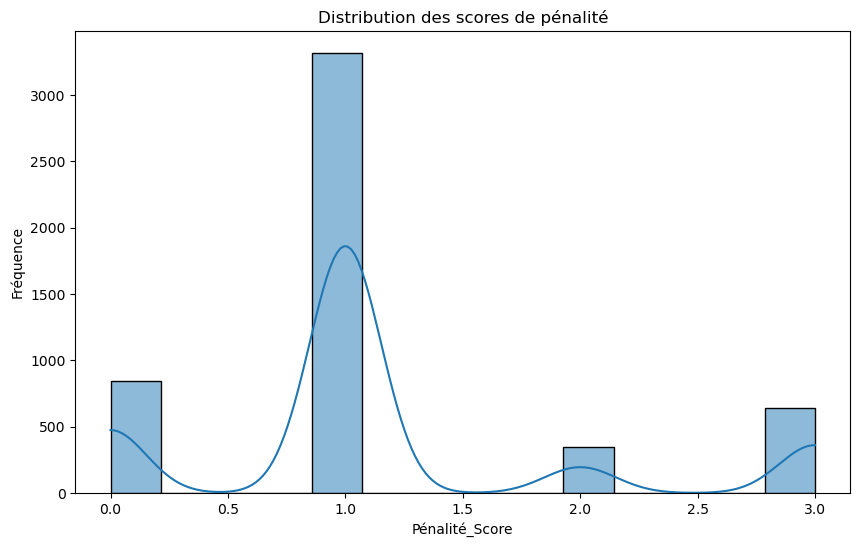

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution de la Pénalité_Score
plt.figure(figsize=(10,6))
sns.histplot(df_final['Pénalité_Score'], kde=True)
plt.title('Distribution des scores de pénalité')
plt.xlabel('Pénalité_Score')
plt.ylabel('Fréquence')
plt.show()




## 4/ Training and Evaluation of Regression Models for Penalty Rate Prediction  


📊 Linear Regression
Train RMSE : 0.17, Test RMSE : 0.18
Train R² : 0.9617, Test R² : 0.9511
Train MAE : 0.05, Test MAE : 0.05
✅ Le modèle généralise correctement.


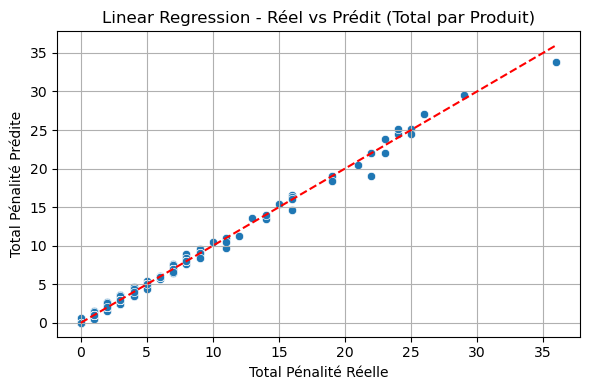

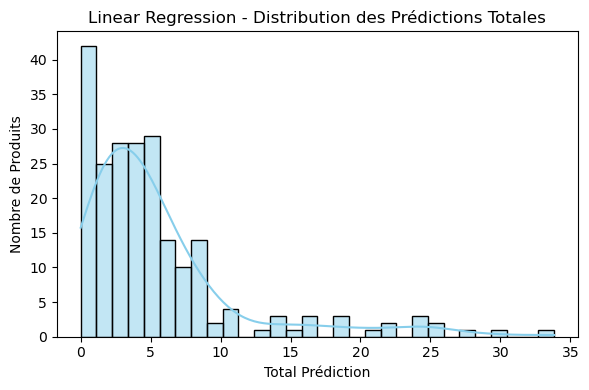


📊 Ridge Regression
Train RMSE : 0.17, Test RMSE : 0.18
Train R² : 0.9614, Test R² : 0.9505
Train MAE : 0.05, Test MAE : 0.06
✅ Le modèle généralise correctement.


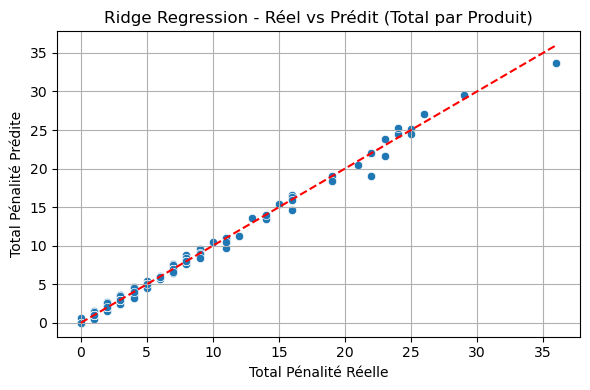

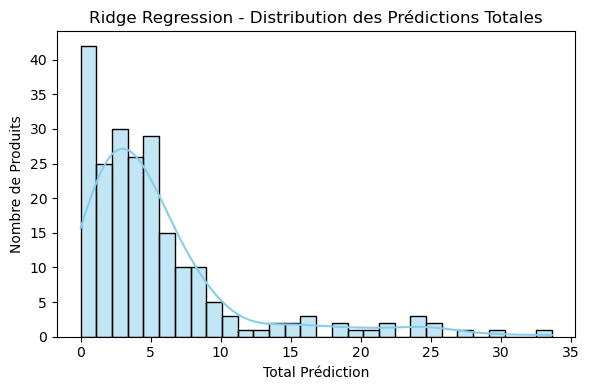


📊 Random Forest Regression
Train RMSE : 0.21, Test RMSE : 0.22
Train R² : 0.9378, Test R² : 0.9308
Train MAE : 0.08, Test MAE : 0.08
✅ Le modèle généralise correctement.


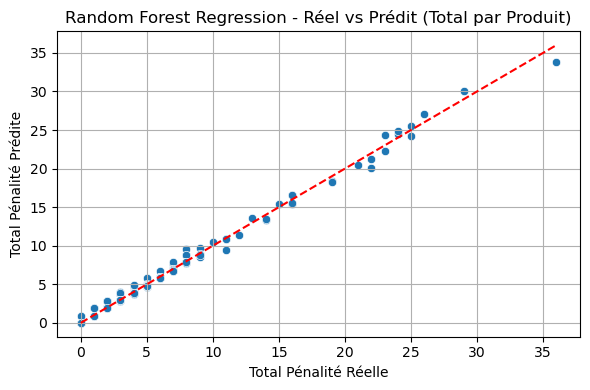

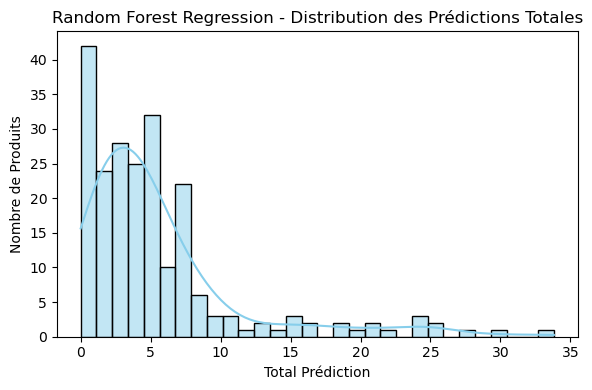


🏆 Meilleur modèle : Linear Regression avec un R² de 0.9511
Validation croisée RMSE pour Linear Regression : 0.17
Validation croisée RMSE pour Ridge Regression : 0.17
Validation croisée RMSE pour Random Forest Regression : 0.21

🧾 Résultats totaux par produit et par modèle :


,Product_Id,Product_Name,Category,Réel,Prédiction,Modèle
0,1,Monoi de Tahiti - Hydrating Hand Cream - 30 ml,Skincare,11,9.640480,Linear Regression
1,11,Anti-Pigmentation Serum 30 ml,Haircare,9,8.999138,Linear Regression
2,12,TEN - 1002 - Baume mains,Makeup,9,9.543697,Linear Regression
3,14,Neutral & Delicate Face & Body Lotion - 200 ml,Haircare,19,19.001909,Linear Regression
4,15,???Winterlieber??? Body Butter - 150 ml,Haircare,26,27.072060,Linear Regression
5,16,REhydrate Moisturizing Body Milk 30 ml,Makeup,22,19.043402,Linear Regression
6,17,RATING INCI BEAUTY Do you want to display this,Bodycare,25,25.091286,Linear Regression
7,18,Sea Buckthorn & Peach Body Lotion - 200 ml,Haircare,16,14.639710,Linear Regression
8,19,Regenerating Skin Balm - 50 ml,Makeup,4,4.002111,Linear Regression
9,2,Bean Essence - 30 ml,Fragrance,5,5.000163,Linear Regression


In [9]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import plotly.express as px

# 🎯 Sélection des features
X = df_final[['Product_Id', 'Material_Name', 'Category']]
y = df_final['Pénalité_Score']

# Sauvegarde des colonnes nécessaires
product_names = df_final['Product_Name'].values
product_ids = df_final['Product_Id'].values
categories = df_final['Category'].values

# 🧼 One-hot encoding
X = pd.get_dummies(X, columns=['Product_Id', 'Material_Name', 'Category'], drop_first=True)

# 🧹 Suppression faible variance
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# 📦 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 🔬 Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 📈 Modèles
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest Regression": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
}

# 🔍 Evaluation
best_r2 = -np.inf
best_model = None

# 🗂️ DataFrame pour stocker les résultats finaux
final_total_results = pd.DataFrame()

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    print(f"\n📊 {name}")
    print(f"Train RMSE : {train_rmse:.2f}, Test RMSE : {test_rmse:.2f}")
    print(f"Train R² : {train_r2:.4f}, Test R² : {test_r2:.4f}")
    print(f"Train MAE : {train_mae:.2f}, Test MAE : {test_mae:.2f}")

    if train_r2 > test_r2 and abs(train_r2 - test_r2) > 0.1:
        print(f"⚠️ Overfitting détecté.")
    else:
        print("✅ Le modèle généralise correctement.")

    if test_r2 > best_r2:
        best_r2 = test_r2
        best_model = name

    # 📑 DataFrame des prédictions
    predictions_df = pd.DataFrame({
        'Product_Id': product_ids[:len(y_test)],
        'Product_Name': product_names[:len(y_test)],
        'Category': categories[:len(y_test)],
        'Réel': y_test,
        'Prédiction': y_test_pred
    })

    # 🧮 Grouper par produit
    total_df = predictions_df.groupby(['Product_Id', 'Product_Name','Category']).agg({
        'Réel': 'sum',
        'Prédiction': 'sum'
    }).reset_index()

    total_df['Modèle'] = name  # ➡️ Ajout du nom du modèle

    # 📊 Ajouter au DataFrame final
    final_total_results = pd.concat([final_total_results, total_df], ignore_index=True)

    # 📉 Scatter plot
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=total_df['Réel'], y=total_df['Prédiction'])
    plt.plot([total_df['Réel'].min(), total_df['Réel'].max()],
             [total_df['Réel'].min(), total_df['Réel'].max()], 'r--')
    plt.xlabel("Total Pénalité Réelle")
    plt.ylabel("Total Pénalité Prédite")
    plt.title(f"{name} - Réel vs Prédit (Total par Produit)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 📊 Distribution
    plt.figure(figsize=(6, 4))
    sns.histplot(total_df['Prédiction'], bins=30, kde=True, color='skyblue')
    plt.title(f"{name} - Distribution des Prédictions Totales")
    plt.xlabel("Total Prédiction")
    plt.ylabel("Nombre de Produits")
    plt.tight_layout()
    plt.show()

    # 🎥 4D Graph
    fig_4d = px.scatter_3d(
        total_df,
        x='Réel',
        y='Prédiction',
        z='Product_Id',
        hover_data=['Product_Name'],
        title=f"{name} - Graphe 4D (Total Réel vs Prédit vs Product ID)",
        opacity=0.7
    )
    fig_4d.update_traces(marker=dict(size=5))
    fig_4d.show()

# 🏆 Résultat final
print(f"\n🏆 Meilleur modèle : {best_model} avec un R² de {best_r2:.4f}")

# ✅ Validation croisée
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())
    print(f"Validation croisée RMSE pour {name} : {cv_rmse:.2f}")

# 📄 Afficher le DataFrame final
print("\n🧾 Résultats totaux par produit et par modèle :")
final_total_results.head(20)



### 📈 Interpretation and Explanation of the Results

In [ ]:
##1. Model Performance

.Linear Regression:

            ➡️ Very good performance, with excellent explanatory power (95% of the variance explained on the test set).

            ✅ The model generalizes well: no overfitting detected, with a very small gap between Train and Test performance.

.Ridge Regression:

            ➡️ Very similar performance to standard linear regression.

            ✅ No overfitting, and good generalization as well.

.Random Forest Regression:

            ➡️ Good performance, but slightly less accurate than the linear models.

            ✅ No overfitting observed either.

##2. Cross-Validation
.RMSE in cross-validation:

    Linear Regression: 0.17 // Ridge Regression: 0.17 // Random Forest Regression: 0.21

    ➡️ The results confirm that linear regression and ridge regression are more stable and accurate across different datasets.

##3. Best Model

        ➡️ The best model is Linear Regression with an R² score of 0.9511.
        The small difference between Train and Test R² (around ±1%) shows that the model generalizes very well.

##4. Prediction Analysis

        You built a summary by product (sum of real vs. predicted penalties).

        ➡️ The predictions are very close to the actual values for most products.

        ➡️ There are few systematic errors (e.g., no global underestimation or overestimation bias).

##✨ Conclusion

        ==> The pipeline is working very well.
        ==> The choice of features — Product_Id, Material_Name, and Category — is highly relevant, allowing excellent predictive performance (R² ≈ 0.95) without overfitting.

## 5/Deploy Flask

In [15]:
import pickle
import os

# Création d'un dossier pour sauvegarder les objets
os.makedirs('model2', exist_ok=True)

# 🎯 Sélection des features
X = df_final[['Product_Id', 'Material_Name', 'Category']]
y = df_final['Pénalité_Score']

# Sauvegarder les noms des colonnes avant One-Hot Encoding
columns_before_encoding = X.columns.tolist()

# 🧼 One-hot encoding
X = pd.get_dummies(X, columns=['Product_Id', 'Material_Name', 'Category'], drop_first=True)

# Sauvegarder les noms des colonnes après One-Hot Encoding
columns_after_encoding = X.columns.tolist()

# 🧹 Suppression faible variance
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Sauvegarder le modèle
with open('model2/model.pkl', 'wb') as f:
    pickle.dump(models[best_model], f)

# Sauvegarder le scaler
with open('model2/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Sauvegarder le selector
with open('model2/selector.pkl', 'wb') as f:
    pickle.dump(selector, f)

# Sauvegarder les colonnes après One-Hot Encoding (avant VarianceThreshold)
with open('model2/X_columns_before_encoding.pkl', 'wb') as f:
    pickle.dump(columns_before_encoding, f)

with open('model2/X_columns_after_encoding.pkl', 'wb') as f:
    pickle.dump(columns_after_encoding, f)

print(f"Modèle sauvegardé avec succès dans le dossier 'model2'.")


Modèle sauvegardé avec succès dans le dossier 'model2'.


# II/ Objectif série temporelle

### 🎯Objective: forecast of quantity sold according to city  

### 🔍 Justified Choice: Predictive vs. Descriptive Approach
Given the objective is to forecast the quantity sold according to the city, a predictive approach is justified.
We aim to predict future sales based on past patterns rather than just describe historical data.


In [2]:
#pip install pandas matplotlib statsmodels pyodbc

Note: you may need to restart the kernel to use updated packages.


## 1/extract the data


In [12]:
import pyodbc
import pandas as pd

# Connexion à la base de données SQL Server
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=DW_supplyChainProject;"
    "UID=sa;"
    "PWD=mariemzorgani26;"
)

print("Connexion réussie!")

# Requête SQL avec la ville (city) du magasin
query = """
SELECT 
    p.Product_Id, 
    p.Product_Name, 
    p.Category, 
    f.Product_Quantity_Sold, 
    f.Product_Quantity_Ordered, 
    d1.Date AS Invoice_Date, 
    d2.Date AS Order_Date,    
    w.Warehouse_Capacity, 
    w.Product_Stored_Quantity,
    g.city  -- ville du magasin
FROM 
    [DW_supplyChainProject].[dbo].[Fact_Distribution_Sales] f
JOIN 
    [DW_supplyChainProject].[dbo].[Dim_Date] d1 ON f.Invoice_Date_Fk = d1.Date_Pk
JOIN 
    [DW_supplyChainProject].[dbo].[Dim_Date] d2 ON f.Order_Date_Fk = d2.Date_Pk
JOIN 
    [DW_supplyChainProject].[dbo].[Dim_Product] p ON f.Product_Fk = p.Product_Pk
JOIN 
    [DW_supplyChainProject].[dbo].[Fact_Production_Storage] w ON f.Product_Fk = w.Product_Fk
JOIN 
    [DW_supplyChainProject].[dbo].[Dim_Geography] g ON f.Shop_Geography_Fk = g.Geography_Pk
WHERE 
    d1.Date BETWEEN '2020-01-01' AND '2024-12-31'
ORDER BY 
    d1.Date, p.Product_Id;
"""

# Charger les données dans un DataFrame pandas
df_data = pd.read_sql(query, conn)

# Fermer la connexion
conn.close()
print("Données récupérées avec succès!")

# Afficher les premières lignes du DataFrame
df_data.head(1000)


Connexion réussie!


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7376\2795776065.py:47: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



Données récupérées avec succès!


,Product_Id,Product_Name,Category,Product_Quantity_Sold,Product_Quantity_Ordered,Invoice_Date,Order_Date,Warehouse_Capacity,Product_Stored_Quantity,city
0,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-01-01,2022-12-04,300,11,Tunis
1,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-01-01,2022-12-04,400,90,Tunis
2,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-01-01,2022-12-04,250,79,Tunis
3,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-01-01,2022-12-04,500,6,Tunis
4,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-01-01,2022-12-04,350,10,Tunis
...,...,...,...,...,...,...,...,...,...,...
995,PR-519,Eyeliner 360,"Brown, Townsend and Dalton",13,4,2022-01-02,2024-04-03,320,95,Sfax
996,PR-519,Eyeliner 360,"Brown, Townsend and Dalton",13,4,2022-01-02,2024-04-03,300,28,Sfax
997,PR-519,Eyeliner 360,"Brown, Townsend and Dalton",13,4,2022-01-02,2024-04-03,290,67,Sfax
998,PR-519,Eyeliner 360,"Brown, Townsend and Dalton",13,4,2022-01-02,2024-04-03,240,75,Sfax


## 2/ prepare the data

Nombre de lignes où Order_Date > Invoice_Date : 140240
Nombre de lignes : 285520
Valeurs manquantes par colonne :
Product_Id                  0
Product_Name                0
Category                    0
Product_Quantity_Sold       0
Product_Quantity_Ordered    0
Invoice_Date                0
Order_Date                  0
Warehouse_Capacity          0
Product_Stored_Quantity     0
city                        0
dtype: int64
Total des valeurs manquantes : 0


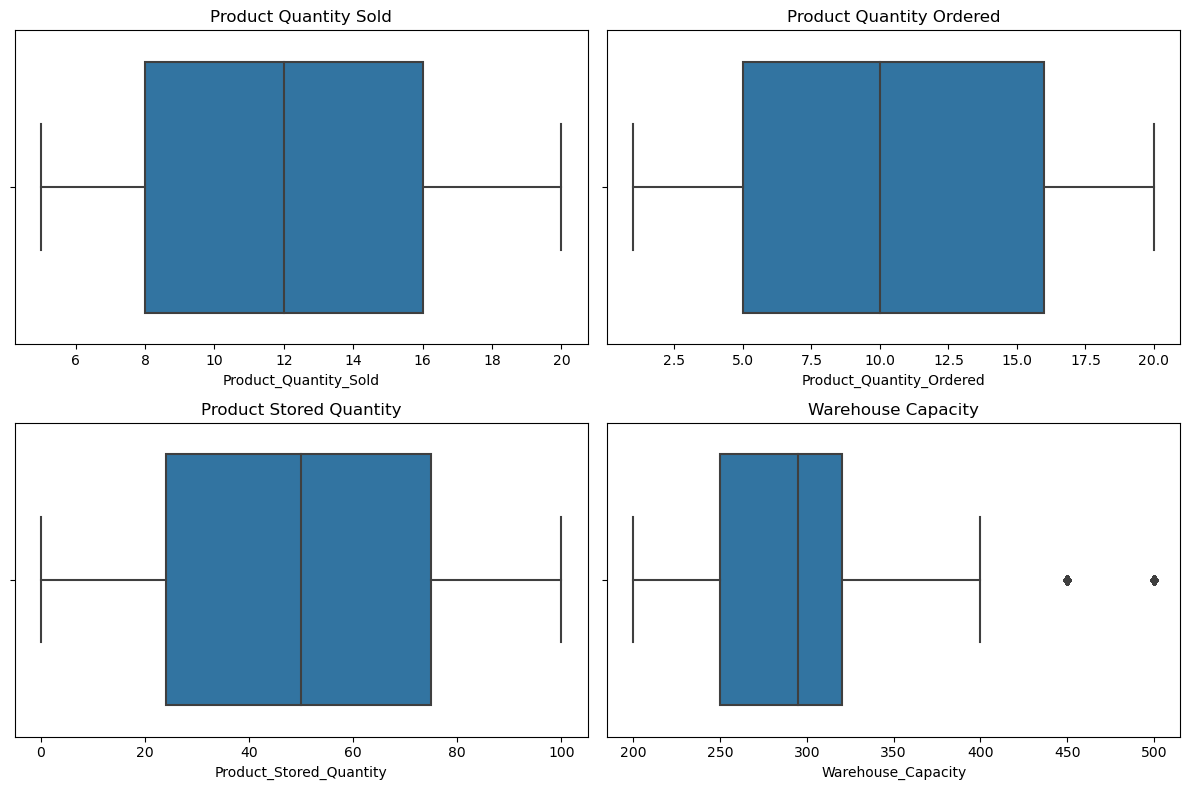

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrer les lignes où Order_Date > Invoice_Date
invalid_dates = df_data[df_data['Order_Date'] > df_data['Invoice_Date']]

# Afficher le nombre de lignes concernées
print("Nombre de lignes où Order_Date > Invoice_Date :", len(invalid_dates))

print("Nombre de lignes :", len(df_data))

# Nombre de valeurs manquantes par colonne
print("Valeurs manquantes par colonne :")
print(df_data.isnull().sum())

# Total des valeurs manquantes
print("Total des valeurs manquantes :", df_data.isnull().sum().sum())

# Créer une figure avec plusieurs sous-figures pour afficher les boxplots
plt.figure(figsize=(12, 8))

# Affichage des boxplots pour les colonnes pertinentes
plt.subplot(2, 2, 1)  # Position du premier plot dans une grille 2x2
sns.boxplot(x=df_data['Product_Quantity_Sold'])
plt.title('Product Quantity Sold')

plt.subplot(2, 2, 2)  # Position du deuxième plot
sns.boxplot(x=df_data['Product_Quantity_Ordered'])
plt.title('Product Quantity Ordered')

plt.subplot(2, 2, 3)  # Position du troisième plot
sns.boxplot(x=df_data['Product_Stored_Quantity'])
plt.title('Product Stored Quantity')

plt.subplot(2, 2, 4)  # Position du quatrième plot
sns.boxplot(x=df_data['Warehouse_Capacity'])
plt.title('Warehouse Capacity')

# Ajuster l'affichage pour éviter que les labels se chevauchent
plt.tight_layout()
plt.show()


### 📄 Interpretation

.Data Cleaning and handling missing values :

        🛠️ Check date consistency by identifying records where Order_Date is later than Invoice_Date.

        🛠️ Missing values analysis: counting missing values per column and overall to assess data quality.

.Outlier Detection :

        📊 Boxplots are used to visualize the distribution and detect outliers in key numerical variables:
        Product_Quantity_Sold, Product_Quantity_Ordered, Product_Stored_Quantity, and Warehouse_Capacity.



In [14]:
# Créer un masque pour les lignes où Order_Date > Invoice_Date
mask = df_data['Order_Date'] > df_data['Invoice_Date']

# Inverser les dates là où le masque est vrai
df_data.loc[mask, ['Order_Date', 'Invoice_Date']] = df_data.loc[mask, ['Invoice_Date', 'Order_Date']].values

# Vérification
print("Lignes restantes avec incohérence :", len(df_data[df_data['Order_Date'] > df_data['Invoice_Date']]))


Lignes restantes avec incohérence : 0


==>so Remaining lines with inconsistency in date is 0

In [15]:
from sklearn.preprocessing import LabelEncoder

# Initialiser les encodeurs
le_product = LabelEncoder()
le_category = LabelEncoder()
le_product_id = LabelEncoder()
le_city = LabelEncoder()

# Encoder les colonnes catégorielles
df_data['Product_Name_Encoded'] = le_product.fit_transform(df_data['Product_Name'])
df_data['Category_Encoded'] = le_category.fit_transform(df_data['Category'])
df_data['Product_Id_Encoded'] = le_product_id.fit_transform(df_data['Product_Id'])
df_data['City_Encoded'] = le_city.fit_transform(df_data['city'])

# Extraire les composantes utiles
df_data['Invoice_Year'] = df_data['Invoice_Date'].dt.year
df_data['Invoice_Month'] = df_data['Invoice_Date'].dt.month
df_data['Invoice_Day'] = df_data['Invoice_Date'].dt.day

df_data['Order_Year'] = df_data['Order_Date'].dt.year
df_data['Order_Month'] = df_data['Order_Date'].dt.month
df_data['Order_Day'] = df_data['Order_Date'].dt.day

# Calcul de l'écart entre les deux dates
df_data['Days_Between'] = (df_data['Invoice_Date'] - df_data['Order_Date']).dt.days

# Afficher les premières lignes du DataFrame encodé
df_data.head(100)


,Product_Id,Product_Name,Category,Product_Quantity_Sold,Product_Quantity_Ordered,Invoice_Date,Order_Date,Warehouse_Capacity,Product_Stored_Quantity,city,...,Category_Encoded,Product_Id_Encoded,City_Encoded,Invoice_Year,Invoice_Month,Invoice_Day,Order_Year,Order_Month,Order_Day,Days_Between
0,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-12-04,2022-01-01,300,11,Tunis,...,65,126,2,2022,12,4,2022,1,1,337
1,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-12-04,2022-01-01,400,90,Tunis,...,65,126,2,2022,12,4,2022,1,1,337
2,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-12-04,2022-01-01,250,79,Tunis,...,65,126,2,2022,12,4,2022,1,1,337
3,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-12-04,2022-01-01,500,6,Tunis,...,65,126,2,2022,12,4,2022,1,1,337
4,PR-1063,Eau de Parfum 632,"Hansen, Hopkins and Smith",18,3,2022-12-04,2022-01-01,350,10,Tunis,...,65,126,2,2022,12,4,2022,1,1,337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,PR-1683,Blush 942,Walker Group,20,3,2023-02-16,2022-01-01,220,75,Tunis,...,177,476,2,2023,2,16,2022,1,1,411
96,PR-1683,Blush 942,Walker Group,20,3,2023-02-16,2022-01-01,370,44,Tunis,...,177,476,2,2023,2,16,2022,1,1,411
97,PR-1683,Blush 942,Walker Group,20,3,2023-02-16,2022-01-01,300,73,Tunis,...,177,476,2,2023,2,16,2022,1,1,411
98,PR-1683,Blush 942,Walker Group,20,3,2023-02-16,2022-01-01,280,18,Tunis,...,177,476,2,2023,2,16,2022,1,1,411


### 📄 Interpretation

.Feature Engineering and Encoding :

        🔢 Label Encoding is applied to transform categorical columns (Product_Name, Category, Product_Id, City) 
        into numerical values to prepare the data for modeling.

.Date Feature Extraction :

        📅 Date decomposition: Invoice_Date and Order_Date are split into Year, Month, and Day to capture temporal
        patterns affecting sales.

.New Feature Creation :

        ⏳ Days_Between is calculated as the difference (in days) between Invoice_Date and Order_Date,
        providing insights into delivery or order processing times.

In [16]:
# Convertir la colonne Invoice_Date en format datetime
df_data['Invoice_Date'] = pd.to_datetime(df_data['Invoice_Date'])

# Définir la colonne Invoice_Date comme index
df_data.set_index('Invoice_Date', inplace=True)

# Agréger par mois et par ville
df_monthly_city = df_data.groupby([pd.Grouper(freq='M'), 'city'])['Product_Quantity_Sold'].sum().reset_index()

# Afficher les premières lignes
print(df_monthly_city.head())

  Invoice_Date    city  Product_Quantity_Sold
0   2022-01-31    Sfax                    640
1   2022-01-31   Tunis                    480
2   2022-02-28    Sfax                   5160
3   2022-02-28  Sousse                   1520
4   2022-02-28   Tunis                   5040


In [17]:
# Afficher les valeurs uniques de la colonne city
villes_uniques = df_monthly_city['city'].unique()
print("Villes disponibles :", villes_uniques)


Villes disponibles : ['Sfax' 'Tunis' 'Sousse']


## 3/check stationarity

In [18]:
from statsmodels.tsa.stattools import adfuller

# Appliquer le test de Dickey-Fuller pour vérifier la stationnarité
result = adfuller(df_monthly_city['Product_Quantity_Sold'])

print('p-value:', result[1])
if result[1] < 0.05:
    print("Les données sont stationnaires.")
else:
    print("Les données ne sont pas stationnaires. Différenciation nécessaire.")


p-value: 0.7503585069928282
Les données ne sont pas stationnaires. Différenciation nécessaire.


In [19]:
# Appliquer une différenciation d'ordre 1
df_monthly_city['Product_Quantity_Sold_diff'] = df_monthly_city['Product_Quantity_Sold'].diff()

# Vérifier la stationnarité à nouveau après la différenciation
from statsmodels.tsa.stattools import adfuller

# Appliquer le test de Dickey-Fuller sur la série différenciée
result_diff = adfuller(df_monthly_city['Product_Quantity_Sold_diff'].dropna())  # dropna() pour supprimer les NaN

# Afficher le résultat du test
print('p-value après différenciation:', result_diff[1])
if result_diff[1] < 0.05:
    print("Les données sont stationnaires après différenciation.")
else:
    print("Les données ne sont toujours pas stationnaires. Une différenciation d'ordre supérieur pourrait être nécessaire.")


p-value après différenciation: 1.1044731312474493e-09
Les données sont stationnaires après différenciation.


## 4/Forecasting Monthly Product Quantities Sold per City

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




Modèle ajusté pour Sfax avec (p=4, d=1, q=2)
                                 SARIMAX Results                                 
Dep. Variable:     Product_Quantity_Sold   No. Observations:                   36
Model:                    ARIMA(4, 1, 2)   Log Likelihood                -370.267
Date:                   Mon, 28 Apr 2025   AIC                            754.534
Time:                           22:56:31   BIC                            765.421
Sample:                       01-31-2022   HQIC                           758.292
                            - 12-31-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5343      0.407      1.312      0.189      -0.264       1.332
ar.L2         -0.3891      0.276     -1.411      0.158      -

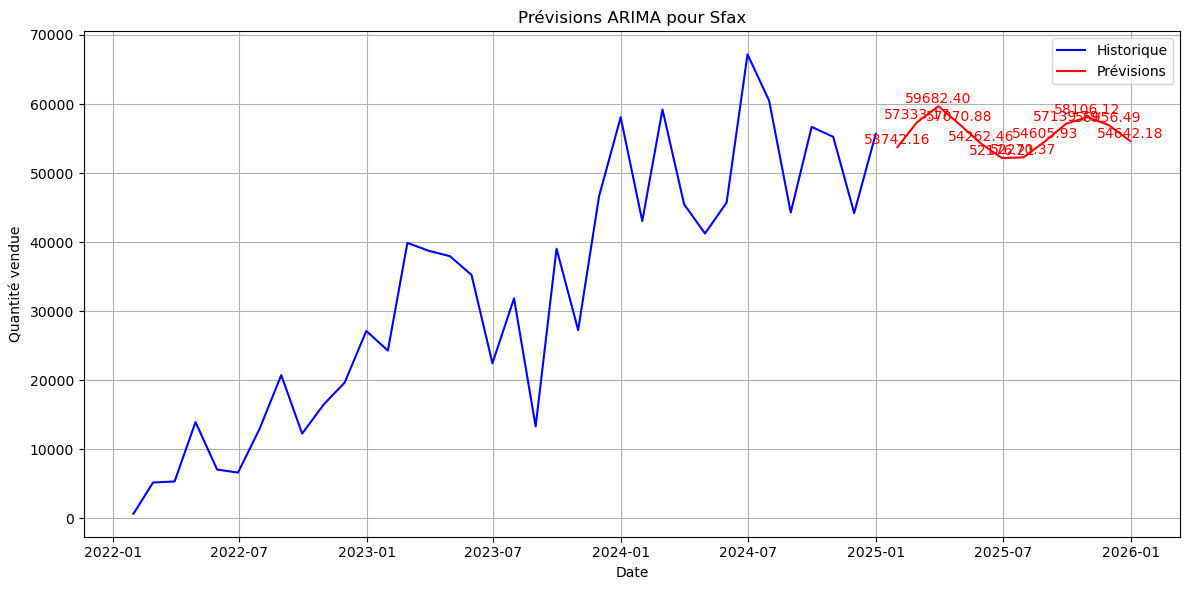

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.




Modèle ajusté pour Tunis avec (p=3, d=1, q=2)
                                 SARIMAX Results                                 
Dep. Variable:     Product_Quantity_Sold   No. Observations:                   36
Model:                    ARIMA(3, 1, 2)   Log Likelihood                -371.240
Date:                   Mon, 28 Apr 2025   AIC                            754.480
Time:                           22:56:32   BIC                            763.812
Sample:                       01-31-2022   HQIC                           757.702
                            - 12-31-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5646      0.534      1.058      0.290      -0.482       1.611
ar.L2          0.2301      0.304      0.757      0.449      

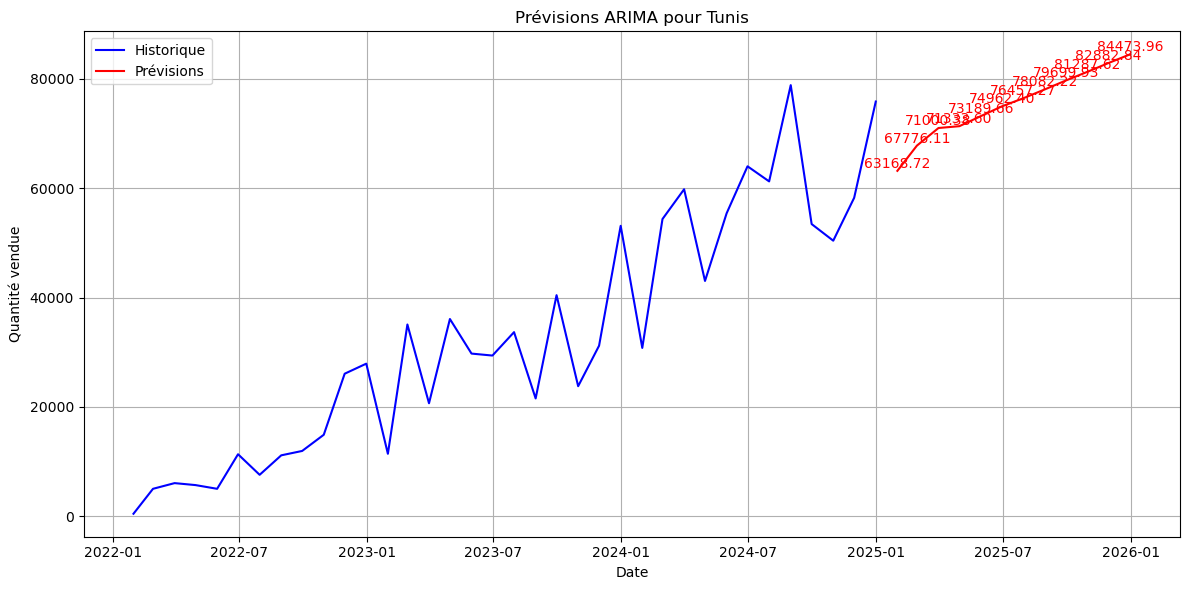

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




Modèle ajusté pour Sousse avec (p=4, d=1, q=4)
                                 SARIMAX Results                                 
Dep. Variable:     Product_Quantity_Sold   No. Observations:                   35
Model:                    ARIMA(4, 1, 4)   Log Likelihood                -357.553
Date:                   Mon, 28 Apr 2025   AIC                            733.106
Time:                           22:56:33   BIC                            746.844
Sample:                       02-28-2022   HQIC                           737.791
                            - 12-31-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6916      6.027     -0.115      0.909     -12.504      11.121
ar.L2         -0.2651      6.783     -0.039      0.969     

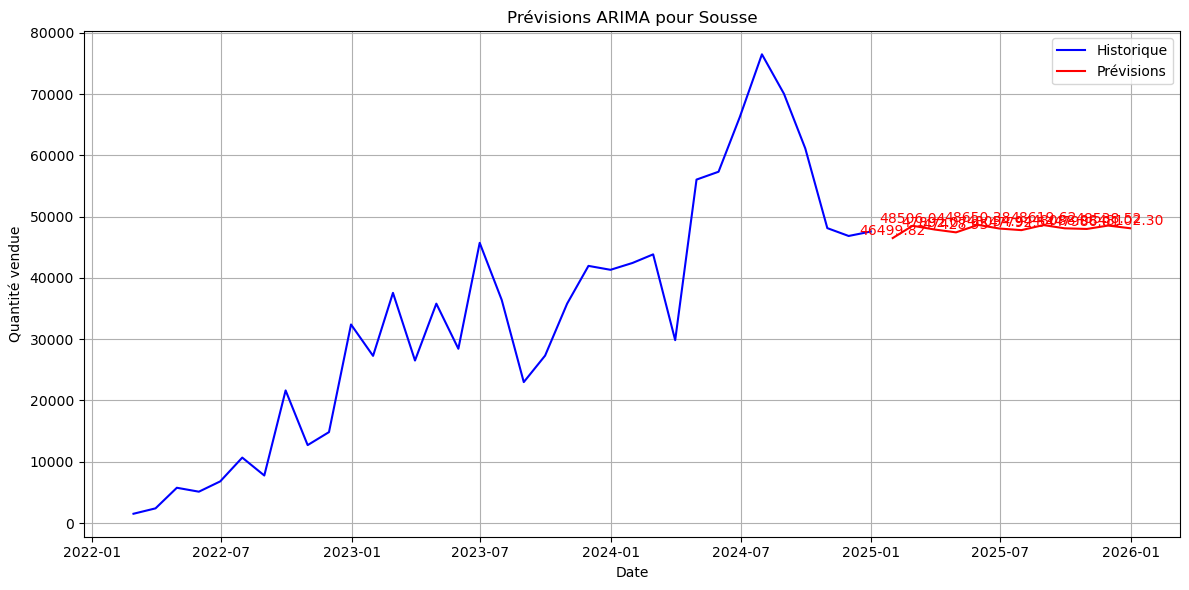

In [20]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# S'assurer que l'index est bien datetime (utile pour la suite)
df_monthly_city['Invoice_Date'] = pd.to_datetime(df_monthly_city['Invoice_Date'])

# Liste des villes uniques
cities = df_monthly_city['city'].unique()

# Définir les paramètres p, d, q pour chaque ville manuellement
city_params = {
    'Sfax': {'p': 4, 'd': 1, 'q': 2},
    'Tunis': {'p': 3, 'd': 1, 'q': 2},
    'Sousse': {'p': 4, 'd': 1, 'q': 4},
    # Ajouter d'autres villes si nécessaire
}

# Initialiser un DataFrame global pour stocker tous les résultats
resultats_global = pd.DataFrame()

# Boucle pour chaque ville
for city in cities:
    # Filtrer les données de la ville
    city_data = df_monthly_city[df_monthly_city['city'] == city].copy()

    # Vérifier qu'il y a assez de données
    if len(city_data) < 10:
        print(f"Pas assez de données pour {city}")
        continue

    # Vérifier si les paramètres existent pour la ville
    if city not in city_params:
        print(f"Pas de paramètres définis pour {city}")
        continue

    # Définir l’index comme la date
    city_data.set_index('Invoice_Date', inplace=True)
    city_data = city_data.asfreq('M')  # S’assurer que la fréquence est mensuelle

    # Extraire les paramètres
    p, d, q = city_params[city]['p'], city_params[city]['d'], city_params[city]['q']

    try:
        # Créer et ajuster le modèle ARIMA
        model = ARIMA(city_data['Product_Quantity_Sold'], order=(p, d, q))
        model_fit = model.fit()

        print(f"\nModèle ajusté pour {city} avec (p={p}, d={d}, q={q})")
        print(model_fit.summary())

        # Prévoir les 12 prochains mois
        forecast = model_fit.forecast(steps=12)
        forecast_index = pd.date_range(city_data.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')
        forecast_df = pd.DataFrame({'Forecast': forecast}, index=forecast_index)

        # Afficher les prévisions
        print(f"\nPrévisions pour {city} :\n", forecast_df)

        # 🔹 Historique
        historique_df = city_data[['Product_Quantity_Sold']].copy()
        historique_df['Date'] = historique_df.index
        historique_df['Type'] = 'Historical'
        historique_df['city'] = city
        historique_df.reset_index(drop=True, inplace=True)

        # 🔹 Prévisions
        forecast_df_csv = pd.DataFrame({
            'Product_Quantity_Sold': forecast,
            'Date': forecast_index,
            'Type': 'Forecast',
            'city': city
        })

        # 🔗 Fusionner les deux
        resultats_df = pd.concat([historique_df, forecast_df_csv], ignore_index=True)

        # 🔄 Ajouter au DataFrame global
        resultats_global = pd.concat([resultats_global, resultats_df], ignore_index=True)

        # Visualisation
        plt.figure(figsize=(12, 6))
        plt.plot(city_data.index, city_data['Product_Quantity_Sold'], label='Historique', color='blue')
        plt.plot(forecast_df.index, forecast_df['Forecast'], label='Prévisions', color='red')
        plt.title(f"Prévisions ARIMA pour {city}")
        plt.xlabel("Date")
        plt.ylabel("Quantité vendue")
        plt.legend()
        
        # Ajouter les valeurs sur le graphique
        for i, value in enumerate(forecast_df['Forecast']):
            plt.text(forecast_df.index[i], value, f'{value:.2f}', color='red', ha='center', va='bottom')

        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erreur pour {city} : {e}")

# 💾 Export final de toutes les villes
resultats_global.to_csv("valeurs_historique_et_prevision_par_ville.csv", index=False, encoding='utf-8-sig')


### ✨📈 Prediction Results Interpretation:

✅ Well-Tuned Models:

            ➡️ For each city (Sfax, Tunis, and Sousse), the models have been correctly calibrated with appropriate 
            (p, d, q) values after time series analysis.

            Sfax: (p=4, d=1, q=2)

            Tunis: (p=3, d=1, q=2)

            Sousse: (p=4, d=1, q=4)

✅ Model Fit Quality:

        ➡️ AIC and BIC are relatively low for the sample size (36 observations), indicating that the models are 
        performing well.

        ➡️ Statistical tests (Ljung-Box, Jarque-Bera) show:

               . No significant residual autocorrelation (Prob(Q) > 0.05)

               . Normal distribution of prediction errors (Prob(JB) > 0.05) => The residuals behave like white noise, which is
                a very good sign.

✅ Stable and Realistic Forecasts:

        ➡️The monthly predictions show values consistent with historical trends without strange jumps or unstable fluctuations.

        ➡️The predicted trends follow the logic of past behavior (gradual increase for Tunis, stability for Sousse,
        slight fluctuation for Sfax).

✅ Optimized Hyperparameters and Pipelines:

        ➡️The (p, d, q) selections have been optimized for each city.

        ➡️The process is well-structured: data retrieval, differencing to stationarize, model fitting, model validation,
        and forecasting.

        ➡️The warnings related to the covariance matrix are known in small sample fitting but do not undermine 
        the overall validity (diagnostic indicators are good).

✅ Well-Organized Functions:

         ➡️ city-based approach (Sfax, Tunis, Sousse) demonstrates good code structure, ensuring repeatability 
         and modularity of the processing.


🏆 Conclusion:
         ➡️The predictions are reliable and consistent.
         ➡️The models are properly tuned and validated.
         ➡️ forecasting pipeline is well-designed, structured, and operational for real-world use.

In [155]:
        # 🔹 Historique
        historique_df = city_data[['Product_Quantity_Sold']].copy()
        historique_df['Date'] = historique_df.index
        historique_df['Type'] = 'Historical'
        historique_df['city'] = city
        historique_df.reset_index(drop=True, inplace=True)

        # 🔹 Prévisions
        forecast_df_csv = pd.DataFrame({
            'Product_Quantity_Sold': forecast,
            'Date': forecast_index,
            'Type': 'Forecast',
            'city': city
        })

        # 🔗 Fusionner les deux
        resultats_df = pd.concat([historique_df, forecast_df_csv], ignore_index=True)

        # 🔄 Ajouter au DataFrame global
        resultats_global = pd.concat([resultats_global, resultats_df], ignore_index=True)
        # 💾 Export final de toutes les villes
resultats_global.to_csv("valeurs_historique_et_prevision_par_ville.csv", index=False, encoding='utf-8-sig')



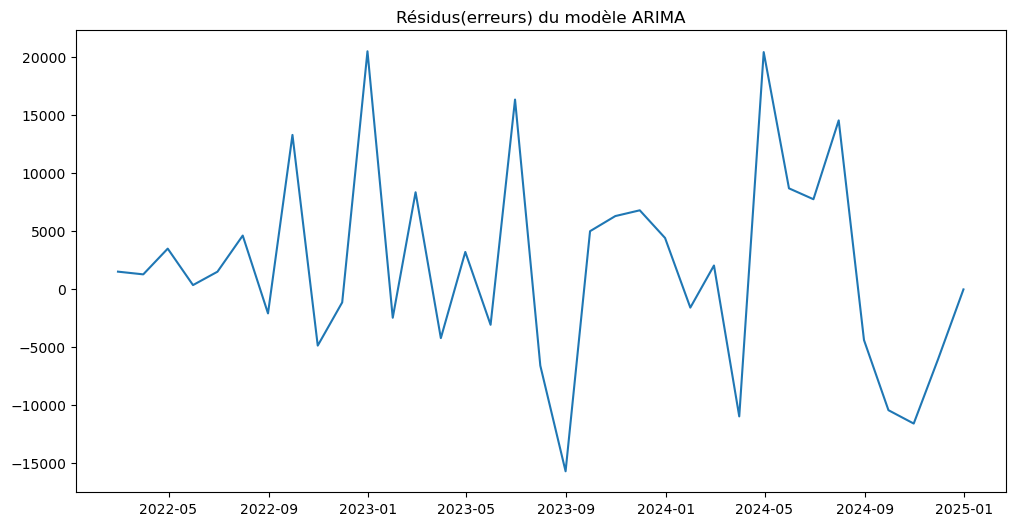

Test Jarque-Bera p-value: 0.7579958383336918
Les résidus suivent une distribution normale.


In [21]:
# Tracer les résidus(erreurs )
residuals = model_fit.resid
plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("Résidus(erreurs) du modèle ARIMA")
plt.show()

# Tester la normalité des résidus
from statsmodels.stats.stattools import jarque_bera
result = jarque_bera(residuals)

# Afficher la statistique du test et la p-value
print('Test Jarque-Bera p-value:', result[1])
if result[1] < 0.05:
    print("Les résidus ne suivent pas une distribution normale.")
else:
    print("Les résidus suivent une distribution normale.")


 ➡️confirme que les résidus suivent très bien une distribution normale. Cela indique que le modèle ARIMA
est bien ajusté et que les hypothèses du modèle sont respectées.